# Collinearity Analysis

Outputs : Results/Collinearity/
- collinearity_heatmap.png  — heatmap of correlated pairs
- vif_scores.csv            — full VIF table
- vif_barplot.png           — ranked VIF bar chart
- vif_vs_corr_scatter.png   — VIF vs max |r| scatter


## Imports

In [81]:
import os
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Config

In [60]:
final_file  = "../data/processed/cardio_onc_prostate_04cleaned.csv"
target_cols = ["at_risk"]          # excluded from features
VIF_THRESH  = 10                   # VIF ≥ 10 = big multicollinearity
CORR_THRESH = 0.5                  # |r| ≥ 0.50 = big pairwise correlation
out_folder  = "Results/Collinearity"
os.makedirs(out_folder, exist_ok=True)

# Plot color scheme (red = flagged, amber = warned, blue = clean)
COL_FLAG = "#E24B4A"
COL_WARN = "#EF9F27"
COL_OK   = "#378ADD"


## 1. Load data

In [61]:
gdf = gpd.read_file(final_file)

#  "" -> NaN for numeric conversions
gdf.replace("", np.nan, inplace=True)

## 2. Recode columns

In [62]:
date_cols = ["nht_auth_date", "nht_start_date", "adt_start_date"]
for col in date_cols:
    gdf[col] = pd.to_datetime(gdf[col], errors="coerce")

gdf["days_auth_to_start"] = (gdf["nht_start_date"] - gdf["nht_auth_date"]).dt.days
gdf["days_adt_to_nht"]    = (gdf["nht_auth_date"]  - gdf["adt_start_date"]).dt.days

num_cols = ["bmi", "age", "sbp", "dbp", "ascvd_10yr"]
for col in num_cols:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

binary_cols = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done",
    "non_onc_provider", "at_risk",
]
for col in binary_cols:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce").astype("Int8")

exclude_cols = ["bp_meds_post", "lipid_meds_post", "dm_meds_post"]
binary_cols  = [c for c in binary_cols if c not in exclude_cols]
gdf.drop(columns=exclude_cols, inplace=True, errors="ignore")

gdf["prescribing_provider"] = gdf["prescribing_provider"].str.strip().str.upper()

cat_cols = ["ethnicity", "specific_nht_used", "adt_agent", "prescribing_provider"]
le_map   = {}   # keep encoders

for col in cat_cols:
    le       = LabelEncoder()
    non_null = gdf[col].notna()
    gdf.loc[non_null, col + "_enc"] = le.fit_transform(
        gdf.loc[non_null, col].astype(str)
    )
    gdf[col + "_enc"] = gdf[col + "_enc"].astype("Int16")
    le_map[col] = le

gdf["unique_patient_id"] = (
    pd.to_numeric(gdf["unique_patient_id"], errors="coerce").astype("Int32")
)

print(gdf.dtypes)
print(f"\nShape: {gdf.shape}")
print(f"Missing values per column:\n{gdf.isnull().sum()[gdf.isnull().sum() > 0]}")


unique_patient_id                    Int32
ethnicity                           object
nht_auth_date               datetime64[ns]
nht_start_date              datetime64[ns]
bmi                                float64
specific_nht_used                   object
age                                float64
adt_start_date              datetime64[ns]
adt_agent                           object
hx_smoking                            Int8
family_hx_hd                          Int8
hx_htn                                Int8
sbp                                float64
dbp                                float64
bp_meds_prior                         Int8
bb_prior                              Int8
ace_arb_prior                         Int8
has_pcp                               Int8
hx_hld                                Int8
hx_high_tg                            Int8
statin_prior                          Int8
other_lipid_prior                     Int8
lipid_panel_checked                   Int8
ascvd_10yr 

## 3. Pairwise Pearson correlation

In [63]:
model_cols = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200", "asa_use",
    "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done", "non_onc_provider",
    "days_auth_to_start", "days_adt_to_nht",
    "ethnicity_enc", "specific_nht_used_enc",
    "adt_agent_enc", "prescribing_provider_enc",
    "at_risk",
]

df_num = gdf[model_cols].apply(pd.to_numeric, errors="coerce")
corr   = df_num.corr(method="pearson")

# Upper triangle mask (no diagonal)
pairs_df = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
pairs_df.columns = ["var1", "var2", "correlation"]
pairs_df = (
    pairs_df[pairs_df["correlation"].abs() >= CORR_THRESH]
    .sort_values("correlation", ascending=False)
    .reset_index(drop=True)
)

print(f"\n{'='*55}")
print(f"  Pairs with |r| >= {CORR_THRESH}  ({len(pairs_df)} found)")
print(f"{'='*55}")
print(pairs_df.to_string(index=False))


  Pairs with |r| >= 0.5  (7 found)
           var1                var2  correlation
    cards_prior          cards_post     0.617638
diet_counseling exercise_counseling     0.616237
         hx_dm2       dm_noninsulin     0.615115
         hx_htn       bp_meds_prior     0.585188
         hx_cad         cards_prior     0.582104
         hx_hld        statin_prior     0.515268
  bp_meds_prior       ace_arb_prior     0.505814


## 4. Correlation heatmap

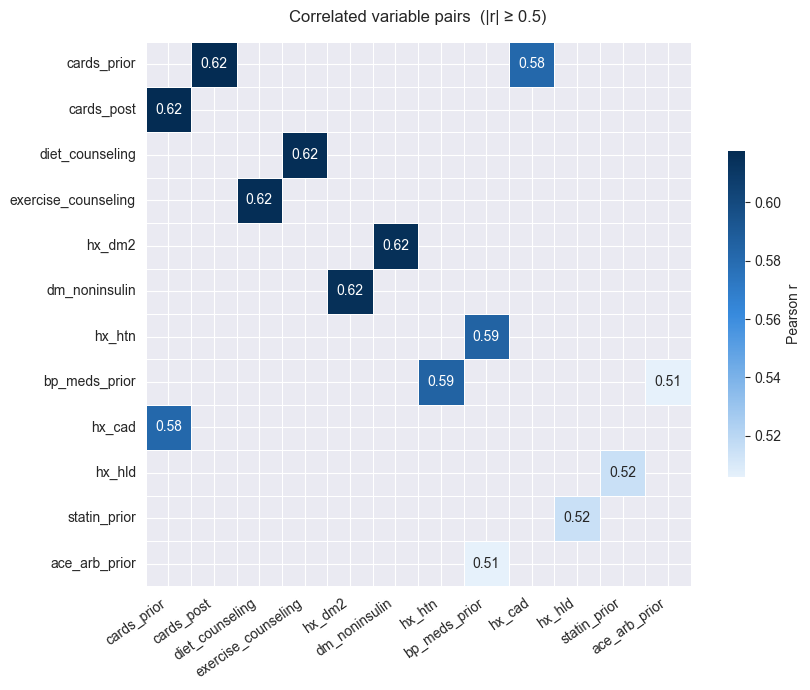

Saved → Results/Collinearity/collinearity_heatmap.png


In [64]:
pairs_list = list(pairs_df.itertuples(index=False))   # named tuples: var1, var2, correlation
vars_      = list(dict.fromkeys([v for p in pairs_list for v in (p.var1, p.var2)]))

mat = pd.DataFrame(np.nan, index=vars_, columns=vars_)
for p in pairs_list:
    mat.loc[p.var1, p.var2] = p.correlation
    mat.loc[p.var2, p.var1] = p.correlation

cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_ramp", ["#E6F1FB", "#378ADD", "#042C53"]
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    mat, ax=ax, cmap=cmap,
    vmin=pairs_df["correlation"].abs().min(),
    vmax=pairs_df["correlation"].abs().max(),
    annot=True, fmt=".2f", annot_kws={"size": 10},
    linewidths=0.5, linecolor="white",
    square=True,
    cbar_kws={"label": "Pearson r", "shrink": 0.6},
    mask=mat.isna(),
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title(f"Correlated variable pairs  (|r| ≥ {CORR_THRESH})", fontsize=12, pad=14)

plt.tight_layout()
heatmap_path = os.path.join(out_folder, "collinearity_heatmap.png")
fig.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {heatmap_path}")


## 5. Variance Inflation Factor (VIF)

In [65]:
drop_before_vif = [
    "unique_patient_id",
    "nht_auth_date", "nht_start_date", "adt_start_date",   # raw datetime
    "prescribing_provider", "ethnicity",                    # original strings
    "specific_nht_used", "adt_agent",                       # (encoded versions kept)
    "bp_meds_post", "lipid_meds_post", "dm_meds_post",     # already dropped
] + target_cols

feature_cols = [c for c in gdf.columns if c not in drop_before_vif]
X = gdf[feature_cols].dropna().astype(float)

vif_df = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))
vif_csv = os.path.join(out_folder, "vif_scores.csv")
vif_df.to_csv(vif_csv, index=False)
print(f"Saved → {vif_csv}")


                 feature         VIF
                     sbp 1396.013581
                     dbp  585.594519
                     age  410.717632
             hx_mi_stent  191.673473
                     bmi  168.615389
            echo_ordered  141.817600
             cards_prior   66.612158
              cards_post   60.911035
              ascvd_10yr   53.887272
           adt_agent_enc   38.348439
           bp_meds_prior   36.350890
            statin_prior   29.389564
prescribing_provider_enc   20.900041
              hx_high_tg   19.483500
          cards_referral   18.892277
           ethnicity_enc   18.337963
         days_adt_to_nht   17.043107
                  hx_hld   15.472021
           dm_noninsulin   15.391698
                  hx_dm2   14.825995
                 has_pcp   14.480174
             a1c_checked   13.588985
        non_onc_provider   11.699760
     lipid_panel_checked   11.309050
         diet_counseling   11.229775
                  hx_htn   10.828601
 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


## 6. Merge VIF with max pairwise |r|

In [66]:
pairs_df["abs_r"] = pairs_df["correlation"].abs()
max_r = {}
for _, row in pairs_df.iterrows():
    for v in [row.var1, row.var2]:
        max_r[v] = max(max_r.get(v, 0), row.abs_r)

vif_df["max_abs_r"] = vif_df["feature"].map(max_r).fillna(0)
vif_df["flagged"]   = (vif_df["VIF"] >= VIF_THRESH) | (vif_df["max_abs_r"] >= CORR_THRESH)

#   RED   — VIF ≥ threshold (severe multicollinearity)
#   AMBER — VIF ok but pairwise |r| ≥ threshold (moderate concern)
#   BLUE  — no flag

def bar_color(row):
    if row.VIF >= VIF_THRESH:        return COL_FLAG
    if row.max_abs_r >= CORR_THRESH: return COL_WARN
    return COL_OK

def scatter_color(row):
    if row.VIF >= VIF_THRESH or row.max_abs_r >= CORR_THRESH: return COL_FLAG
    return COL_OK

## 7. VIF bar plot

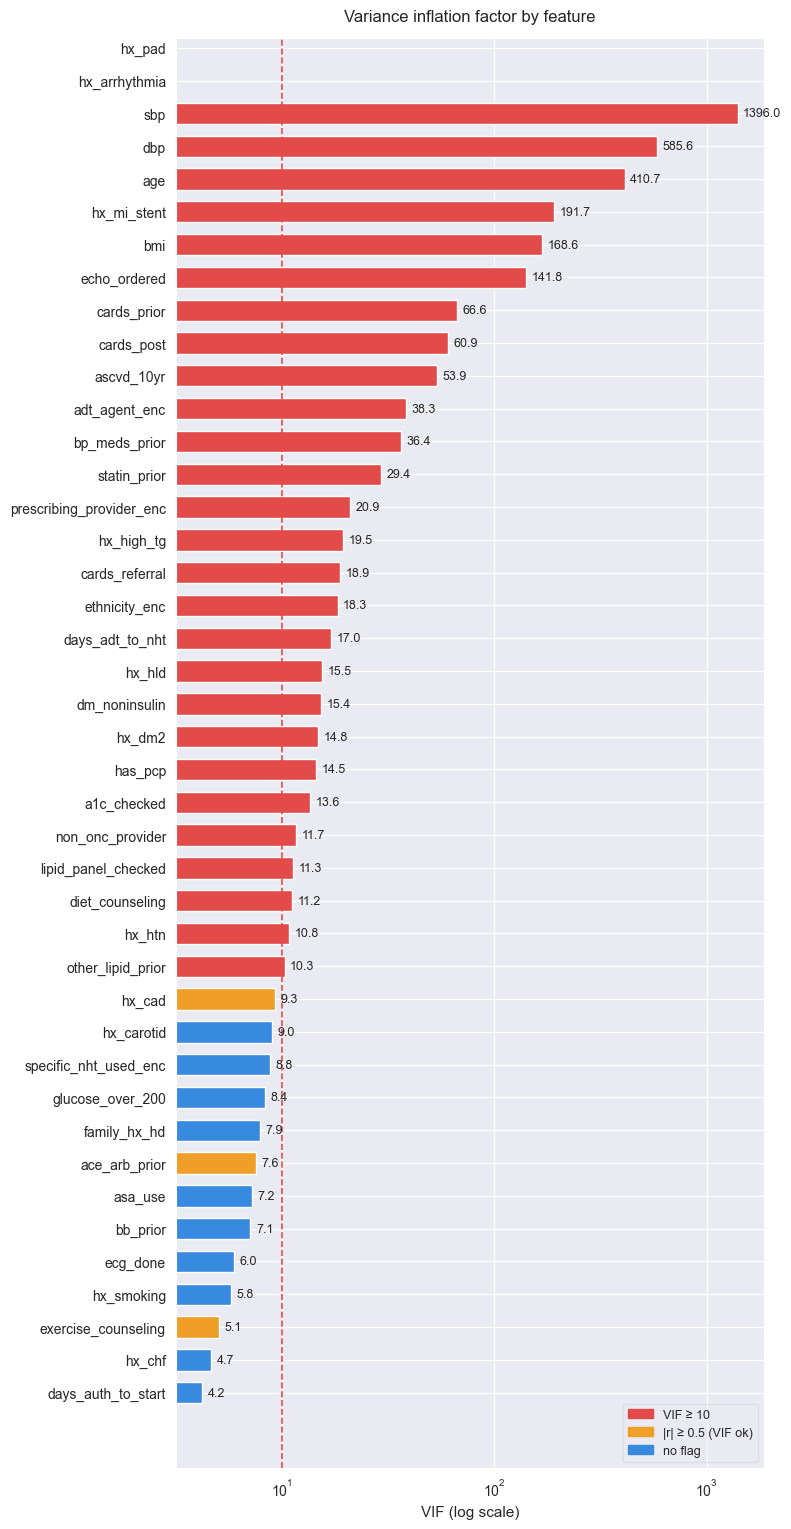

Saved → Results/Collinearity/vif_barplot.png


In [94]:
bar_df = vif_df.sort_values("VIF", ascending=True)
colors = [bar_color(r) for _, r in bar_df.iterrows()]

fig, ax = plt.subplots(figsize=(8, max(5, len(bar_df) * 0.35)))
bars = ax.barh(bar_df["feature"], bar_df["VIF"], color=colors, height=0.65)

ax.axvline(VIF_THRESH, color=COL_FLAG, lw=1.2, ls="--")
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("VIF (log scale)", fontsize=11)
ax.set_title("Variance inflation factor by feature", fontsize=12, pad=12)
ax.xaxis.set_minor_locator(ticker.LogLocator())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COL_FLAG, label=f"VIF ≥ {VIF_THRESH}"),
    plt.Rectangle((0, 0), 1, 1, color=COL_WARN, label=f"|r| ≥ {CORR_THRESH} (VIF ok)"),
    plt.Rectangle((0, 0), 1, 1, color=COL_OK,   label="no flag"),
]
ax.legend(handles=legend_patches, fontsize=9, framealpha=0.4)

plt.tight_layout()
bar_path = os.path.join(out_folder, "vif_barplot.png")
fig.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {bar_path}")


## 8. VIF vs max |r| scatter

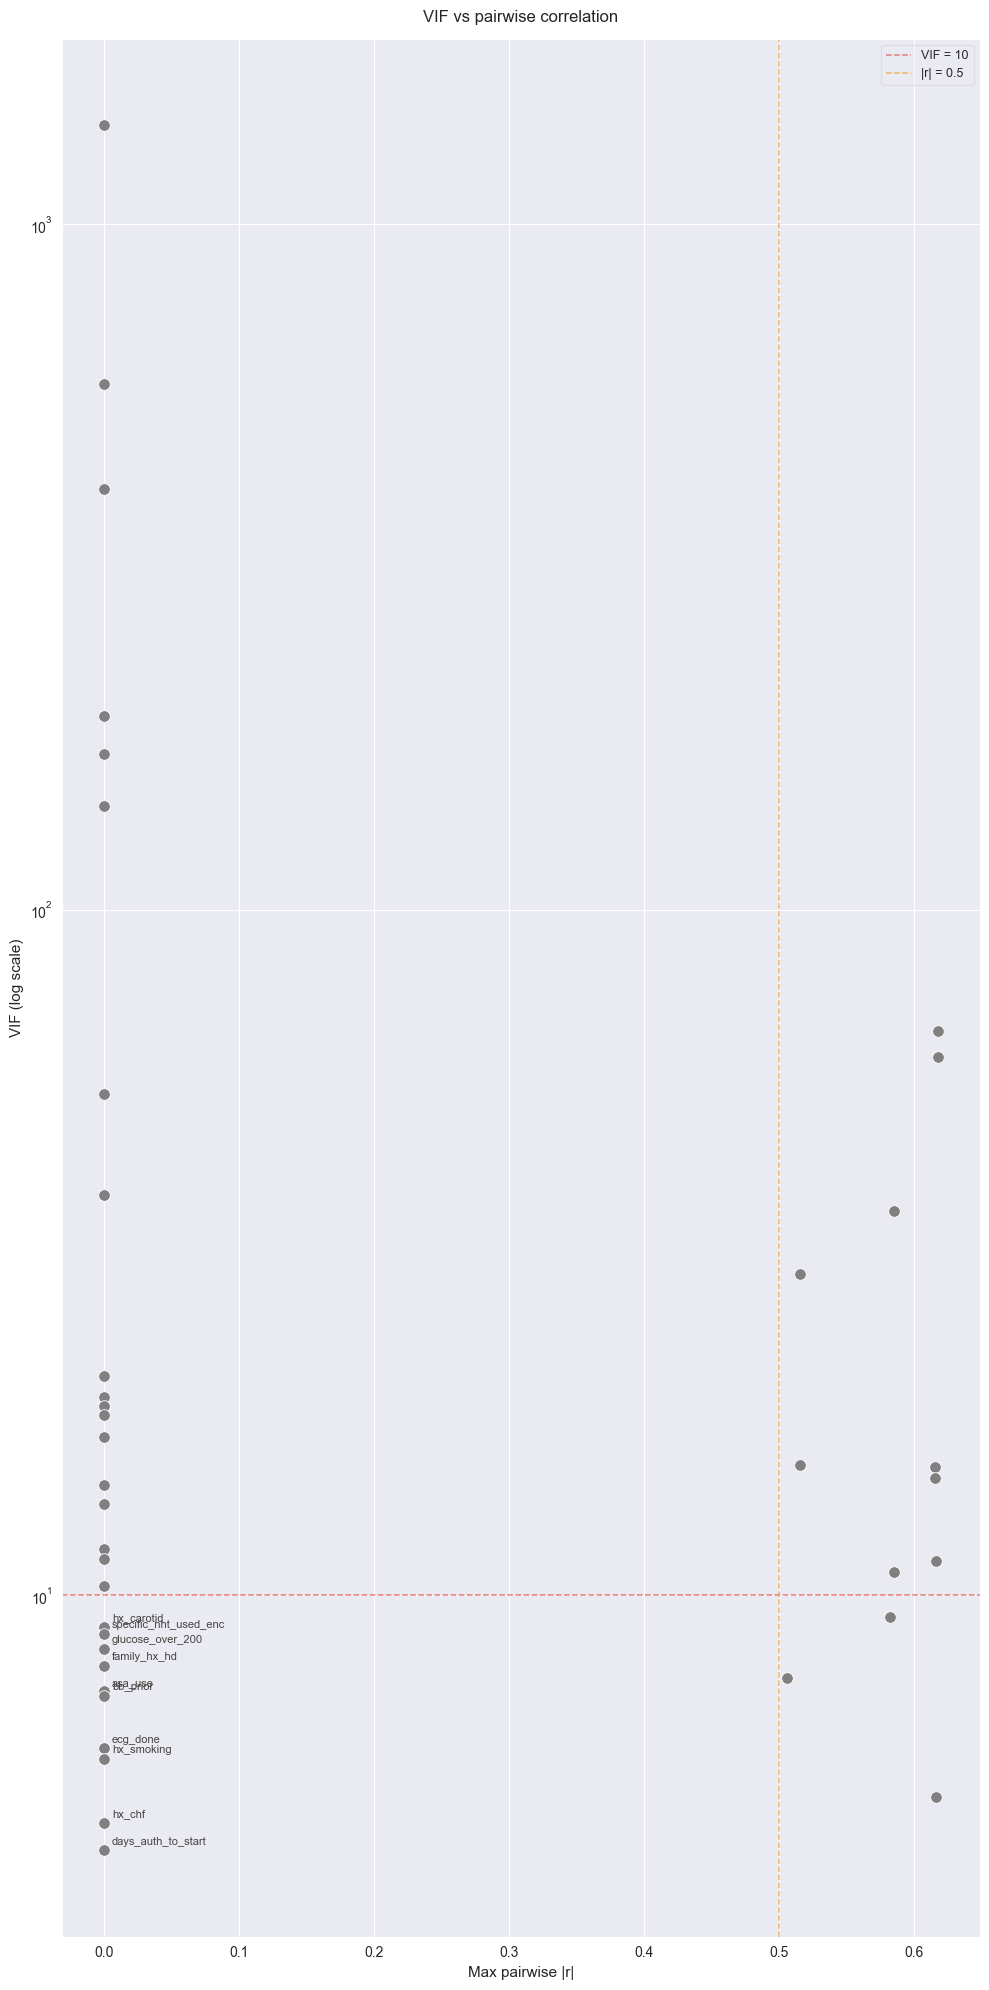

Saved → Results/Collinearity/vif_vs_corr_scatter.png


In [93]:
fig, ax = plt.subplots(figsize=(10, 20))

ax.scatter(
    vif_df["max_abs_r"], vif_df["VIF"],
    color="grey",
    s=70,
    edgecolors="white",
    lw=0.6,
    zorder=3,
)
ax.axhline(VIF_THRESH,  color=COL_FLAG, lw=1.1, ls="--", alpha=0.7, label=f"VIF = {VIF_THRESH}")
ax.axvline(CORR_THRESH, color=COL_WARN, lw=1.1, ls="--", alpha=0.7, label=f"|r| = {CORR_THRESH}")

mask = (vif_df["VIF"] < VIF_THRESH) & (vif_df["max_abs_r"] < CORR_THRESH)

for _, row in vif_df[mask].iterrows():
    ax.annotate(
        row["feature"],
        xy=(row["max_abs_r"], row["VIF"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=8,
        color="#444441",
    )

ax.set_yscale("log")
ax.set_xlabel("Max pairwise |r|", fontsize=11)
ax.set_ylabel("VIF (log scale)", fontsize=11)
ax.set_title("VIF vs pairwise correlation", fontsize=12, pad=12)
ax.legend(fontsize=9, framealpha=0.4)

plt.tight_layout()
scatter_path = os.path.join(out_folder, "vif_vs_corr_scatter.png")
fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {scatter_path}")

In [95]:
pairs = [
    ("cards_prior", "cards_post"),
    ("diet_counseling", "exercise_counseling"),
    ("hx_dm2", "dm_noninsulin"),
    ("hx_htn", "bp_meds_prior"),
    ("hx_cad", "cards_prior"),
    ("hx_hld", "statin_prior"),
    ("bp_meds_prior", "ace_arb_prior"),
]

results = []

for v1, v2 in pairs:
    vif1 = vif_df.loc[vif_df["feature"] == v1, "VIF"].values[0]
    vif2 = vif_df.loc[vif_df["feature"] == v2, "VIF"].values[0]

    better = v1 if vif1 < vif2 else v2

    results.append({
        "var1": v1,
        "var2": v2,
        "VIF_var1": round(vif1, 2),
        "VIF_var2": round(vif2, 2),
        "better_variable": better
    })

pd.DataFrame(results)

,var1,var2,VIF_var1,VIF_var2,better_variable
0,cards_prior,cards_post,66.61,60.91,cards_post
1,diet_counseling,exercise_counseling,11.23,5.08,exercise_counseling
2,hx_dm2,dm_noninsulin,14.83,15.39,hx_dm2
3,hx_htn,bp_meds_prior,10.83,36.35,hx_htn
4,hx_cad,cards_prior,9.31,66.61,hx_cad
5,hx_hld,statin_prior,15.47,29.39,hx_hld
6,bp_meds_prior,ace_arb_prior,36.35,7.57,ace_arb_prior
